In [1]:
import nibabel as nib
import matplotlib.pyplot as plt
import numpy as np


In [2]:
file_path = '/data/hpc/dqm/unetr_plus_plus/output_synapse/unetr_pp/3d_fullres/Task002_Synapse/unetr_pp_trainer_synapse__unetr_pp_Plansv2.1/fold_0/validation_raw_postprocessed/img0001.nii.gz'

file_path = '/data/hpc/dqm/research-contributions/SwinUNETR/BRATS21/outputs/test1/BraTS2021_00006.nii.gz'

Shape of the data: (240, 240, 155)


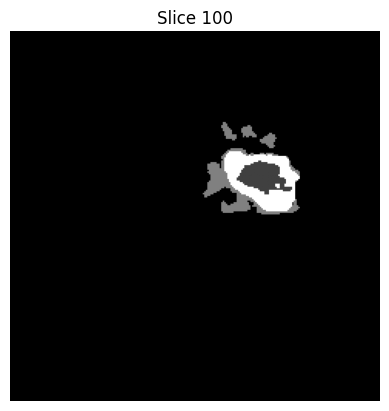

In [82]:

file_path = '/data/hpc/dqm/research-contributions/SwinUNETR/BRATS21/outputs/test1/BraTS2021_01282.nii.gz'

nii_data = nib.load(file_path)

# Trích xuất dữ liệu từ file NIfTI
image_data = nii_data.get_fdata()  # Dữ liệu ảnh 3D (hoặc 4D)

# Kiểm tra kích thước dữ liệu
print("Shape of the data:", image_data.shape)

# Hiển thị một lát cắt (slice) của ảnh 3D
slice_index = 100  # Chọn lát cắt giữa
plt.imshow(image_data[:, :, slice_index], cmap="gray")
plt.title(f"Slice {slice_index}")
plt.axis("off")
plt.show()

In [54]:
print(image_data[:, :, slice_index].max())
np.any(image_data[:, :, slice_index] == 4.0)


4.0


True

Shape of the data: (240, 240, 155)


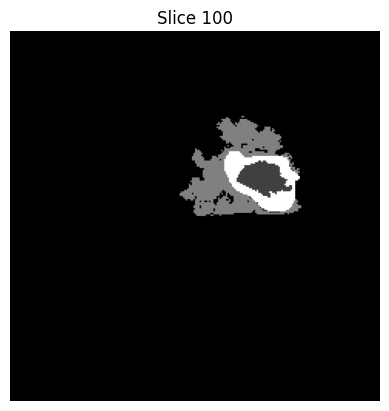

In [83]:
# seg: label
file_path_label = '/data/hpc/dqm/data/brats-2021/TrainingData/BraTS2021_01282/BraTS2021_01282_seg.nii.gz'

nii_data_label = nib.load(file_path_label)

# Trích xuất dữ liệu từ file NIfTI
image_data_label = nii_data_label.get_fdata()  # Dữ liệu ảnh 3D (hoặc 4D)
# Kiểm tra kích thước dữ liệu
print("Shape of the data:", image_data_label.shape)

# Hiển thị một lát cắt (slice) của ảnh 3D
slice_index = 100  # Chọn lát cắt giữa
plt.imshow(image_data_label[:, :, slice_index], cmap="gray")
plt.title(f"Slice {slice_index}")
plt.axis("off")
plt.show()

In [56]:
image_data_label[:, :, slice_index]

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

In [58]:
print(image_data_label[:, :, slice_index].max())
np.any(image_data_label[:, :, slice_index] == 2.0)


4.0


True

Shape of the data: (240, 240, 155)


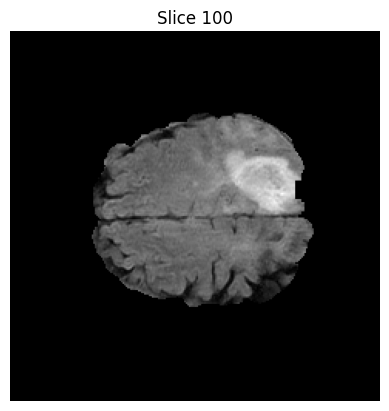

In [91]:
# seg: label
ori_path = '/data/hpc/dqm/data/brats-2021/TrainingData/BraTS2021_01282/BraTS2021_01282_flair.nii.gz'

nii_data_ori = nib.load(ori_path)

# Trích xuất dữ liệu từ file NIfTI
nii_data_ori = nii_data_ori.get_fdata()  # Dữ liệu ảnh 3D (hoặc 4D)
# Kiểm tra kích thước dữ liệu
print("Shape of the data:", nii_data_ori.shape)

# Hiển thị một lát cắt (slice) của ảnh 3D
slice_index = 100  # Chọn lát cắt giữa
plt.imshow(nii_data_ori[:, :, slice_index], cmap="gray")
plt.title(f"Slice {slice_index}")
plt.axis("off")
plt.show()

In [69]:
!pip install opencv-python

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.5/62.5 MB 4.1 MB/s eta 0:00:0000:0100:01m


In [5]:
import numpy as np
import cv2

def mask_overlay(image, mask, color_map, alpha=0.5):
    """
    Overlay a mask with multiple colors on top of the grayscale image.
    
    Args:
        image (np.ndarray): Grayscale image (H x W or H x W x 3).
        mask (np.ndarray): Mask with pixel values representing different classes (H x W).
        color_map (dict): Dictionary mapping mask values to RGB colors, e.g., {1: (0, 255, 0), 2: (255, 255, 0)}.
    
    Returns:
        np.ndarray: Image with the mask overlaid.
    """
    # Ensure image is 3-channel (convert grayscale to RGB if needed)
    if image.dtype != np.uint8:  # Đảm bảo ảnh là uint8
        image = (image * 255).astype(np.uint8)
    
    if len(image.shape) == 2:  # Grayscale
        image = cv2.cvtColor(image, cv2.COLOR_GRAY2BGR)
    
    # Create a copy of the original image
    overlay_image = image.copy()
    
    for mask_value, color in color_map.items():
        # Create a binary mask for the current mask value
        binary_mask = (mask == mask_value).astype(np.uint8)
        
        # Create a color mask for the current mask value
        color_mask = np.dstack([
            binary_mask * color[0],  # Red channel
            binary_mask * color[1],  # Green channel
            binary_mask * color[2],  # Blue channel
        ]).astype(np.uint8)
        
        # Blend the color mask with the original image
        weighted_sum = cv2.addWeighted(color_mask, alpha, overlay_image, 1-alpha, 0.0)
        
        # Apply the mask only on the relevant regions
        overlay_image[binary_mask > 0] = weighted_sum[binary_mask > 0]
    
    return overlay_image


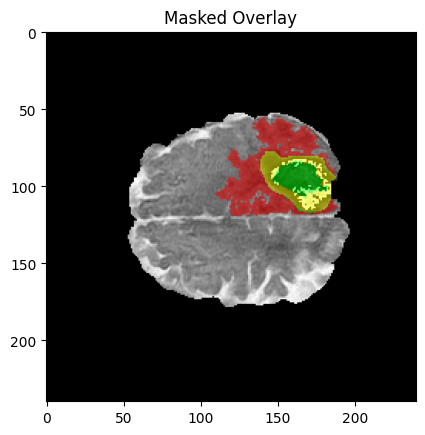

In [106]:
import numpy as np
import matplotlib.pyplot as plt

# Ảnh grayscale 2D
grayscale = nii_data_ori[:, :, slice_index]

# Mask 2D có các giá trị 0, 1, 2, 4
mask = image_data_label[:, :, slice_index]

# Bản đồ màu: (1: xanh, 2: đỏ, 3: vàng)
# 0: giữ nguyên ảnh grayscale
color_map = {
    1.0: [0, 255, 0],  # Xanh
    2.0: [255, 0, 0],  # Đỏ
    4.0: [255, 255, 0],  # Vàng
}

# Áp dụng hàm
result_image = mask_overlay(grayscale, mask, color_map)

# Hiển thị kết quả
import matplotlib.pyplot as pl

plt.title("Masked Overlay")
plt.imshow(result_image)  # Chuyển từ BGR sang RGB để hiển thị

plt.show()


In [5]:
image_data.max()

13.0

In [29]:
label = '/data/hpc/dqm/data/DATASET_Synapse/unetr_pp_raw/unetr_pp_cropped_data/Task002_Synapse/gt_segmentations/label0004.nii.gz'

Shape of the data: (512, 512, 147)


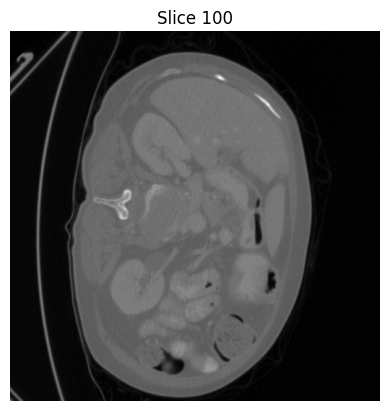

In [30]:

nii_data = nib.load(file_path)

# Trích xuất dữ liệu từ file NIfTI
image_data = nii_data.get_fdata()  # Dữ liệu ảnh 3D (hoặc 4D)

# Kiểm tra kích thước dữ liệu
print("Shape of the data:", image_data.shape)

# Hiển thị một lát cắt (slice) của ảnh 3D
slice_index = 100  # Chọn lát cắt giữa
plt.imshow(image_data[:, :, slice_index], cmap="gray")
plt.title(f"Slice {slice_index}")
plt.axis("off")
plt.show()

In [19]:
image_data.max()

2639.0

In [20]:
nii_data

# BTCV


Shape of the data: (512, 512, 94)


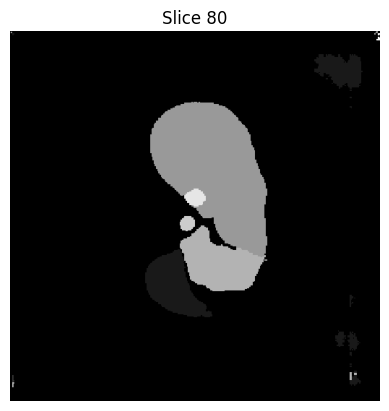

In [4]:

file_path = '/data/hpc/dqm/research-contributions/SwinUNETR/BTCV/outputs/test1/img0035.nii.gz'

nii_data = nib.load(file_path)

# Trích xuất dữ liệu từ file NIfTI
image_data = nii_data.get_fdata()  # Dữ liệu ảnh 3D (hoặc 4D)

# Kiểm tra kích thước dữ liệu
print("Shape of the data:", image_data.shape)

# Hiển thị một lát cắt (slice) của ảnh 3D
slice_index = 80  # Chọn lát cắt giữa
plt.imshow(image_data[:, :, slice_index], cmap="gray")
plt.title(f"Slice {slice_index}")
plt.axis("off")
plt.show()

Shape of the data: (512, 512, 94)


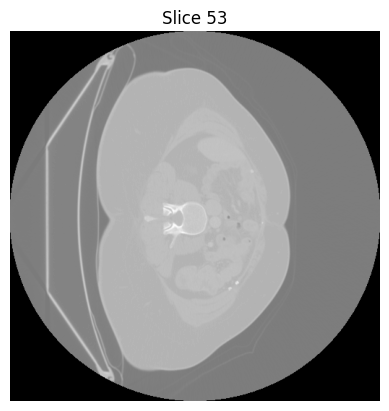

In [14]:
# seg: label
ori_path = '/data/hpc/dqm/research-contributions/UNETR/BTCV/dataset/dataset0/imagesTr/img0035.nii.gz'

nii_data_ori = nib.load(ori_path)

# Trích xuất dữ liệu từ file NIfTI
nii_data_ori = nii_data_ori.get_fdata()  # Dữ liệu ảnh 3D (hoặc 4D)
# Kiểm tra kích thước dữ liệu
print("Shape of the data:", nii_data_ori.shape)

# Hiển thị một lát cắt (slice) của ảnh 3D
slice_index = 53  # Chọn lát cắt giữa
plt.imshow(nii_data_ori[:, :, slice_index], cmap="gray")
plt.title(f"Slice {slice_index}")
plt.axis("off")
plt.show()

In [9]:
print(image_data[:, :, slice_index].max())
np.any(image_data[:, :, slice_index] == 2.0)


0.0

Shape of the data: (512, 512, 94)


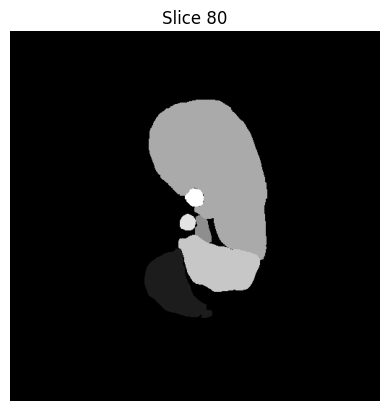

In [11]:
label_tr_path = '/data/hpc/dqm/research-contributions/UNETR/BTCV/dataset/dataset0/labelsTr/label0035.nii.gz'

nii_data_label_tr = nib.load(label_tr_path)

# Trích xuất dữ liệu từ file NIfTI
nii_data_label_tr = nii_data_label_tr.get_fdata()  # Dữ liệu ảnh 3D (hoặc 4D)
# Kiểm tra kích thước dữ liệu
print("Shape of the data:", nii_data_label_tr.shape)

# Hiển thị một lát cắt (slice) của ảnh 3D
slice_index = 80  # Chọn lát cắt giữa
plt.imshow(nii_data_label_tr[:, :, slice_index], cmap="gray")
plt.title(f"Slice {slice_index}")
plt.axis("off")
plt.show()

In [12]:
print(nii_data_label_tr[:, :, slice_index].max())
np.any(nii_data_label_tr[:, :, slice_index] == 2.0)

9.0


False